<a href="https://colab.research.google.com/github/prithviemmidi/LifeSatisfactionAnalysis/blob/main/Decision_Tree_V.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [244]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import io
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.tree import plot_tree
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from cubist import Cubist

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [245]:
path = "/content/drive/MyDrive/lifesat_csv.csv"
df_old = pd.read_csv(path)
df_old.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,member34,othersize,pomst,agesq,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid
0,68035365,45,1981.589,1,0,0,0,0,0,1,...,0,0,0.00000,2025,1.134772,1.7147,1.33485,0.318156,-0.471428,1
1,68035365,46,2110.081,1,0,0,0,0,0,1,...,0,0,33.33333,2116,1.134772,1.7147,1.33485,0.318156,-0.471428,2
2,68035365,46,2351.826,1,0,0,0,0,0,1,...,0,0,66.66666,2116,1.134772,1.7147,1.33485,0.318156,-0.471428,3
3,68035365,48,2219.140,1,0,0,0,0,0,1,...,0,0,66.66666,2304,1.134772,1.7147,1.33485,0.318156,-0.471428,4
4,68035365,49,2498.854,1,0,0,0,0,0,1,...,0,0,50.00000,2401,1.134772,1.7147,1.33485,0.318156,-0.471428,5


In [246]:
df_old["incomecpi"] = pd.to_numeric(df_old["incomecpi"], errors="coerce")

df_old["lincome"] = np.where(df_old["incomecpi"] > 0, np.log(df_old["incomecpi"]), np.nan)
df_old["lincome_sq"] = df_old["lincome"] ** 2

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


aggregate rules

In [247]:
edu_cols = ['neduc','ueduc','oheduc','Alevel','gcse','otheduc']
marital_cols = ['single','married','others']
employment_cols = ['selfemploy','employed','unemploy','retired','sick','familycare','student']
household_cols = ['onemember','twomember','member34','othersize']
trait_cols = [
    'openness_std','neuroticism_std','agreeableness_std',
    'extraversion_std','conscientiousness_std']

In [248]:
agg_rules = {}

for col in df_old.columns:
    if col == 'pidp':
        continue
    elif col in ['male'] + trait_cols:
        agg_rules[col] = 'first'
    elif col in edu_cols:
        agg_rules[col] = 'max'
    else:
        agg_rules[col] = 'mean'

df = df_old.groupby('pidp').agg(agg_rules).reset_index()

print(f"Original rows in df_old: {len(df_old)}")
print(f"Unique individuals in df: {len(df)}")

Original rows in df_old: 25128
Unique individuals in df: 1047




```
Sorting into categorical variables
```



In [249]:
df["genders"] = df["male"].map({0: "Female", 1: "Male"})
df['marital_status'] = df[['single','married','others']].idxmax(axis=1)
df['employment_status'] = df[['selfemploy','employed','unemploy','retired','sick','familycare','student']].idxmax(axis=1)
df['household_size'] = df[['onemember','twomember','member34','othersize']].idxmax(axis=1)

In [250]:
df['education'] = df[['neduc','ueduc','oheduc','Alevel','gcse','otheduc']].idxmax(axis=1)
education_labels = {
    'neduc': 'None',
    'gcse': 'GCSE',
    'Alevel': 'A-level',
    'otheduc': 'Other ',
    'ueduc': 'University',
    'oheduc': 'Other Higher'}
df['education'] = df['education'].map(education_labels)

In [251]:
traits = [
    'openness_std',
    'neuroticism_std',
    'agreeableness_std',
    'extraversion_std',
    'conscientiousness_std']

In [252]:
df.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,extraversion_std,conscientiousness_std,yearid,lincome,lincome_sq,genders,marital_status,employment_status,household_size,education
0,68035365,57.041667,2493.496375,1,0,0,0,0,0,1,...,0.318156,-0.471428,12.5,7.793500,60.797778,Male,others,employed,onemember,Other
1,68058485,64.291667,4008.875375,1,0,0,0,0,1,0,...,-0.449034,-0.471428,12.5,8.152248,66.704068,Male,married,retired,twomember,GCSE
2,68058489,64.291667,4008.875375,0,0,0,0,0,0,1,...,-0.449034,-0.471428,12.5,8.152248,66.704068,Female,married,retired,twomember,Other
3,68064609,57.291667,4231.804125,0,0,0,0,0,1,0,...,1.085346,1.368915,12.5,8.226963,67.930656,Female,married,employed,twomember,GCSE
4,68097245,58.791667,1964.208062,0,0,0,0,0,1,0,...,1.852535,-0.471428,12.5,7.398608,55.095662,Female,others,employed,onemember,GCSE


In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pidp                   1047 non-null   int64  
 1   agenew                 1047 non-null   float64
 2   incomecpi              1047 non-null   float64
 3   male                   1047 non-null   int64  
 4   neduc                  1047 non-null   int64  
 5   ueduc                  1047 non-null   int64  
 6   oheduc                 1047 non-null   int64  
 7   Alevel                 1047 non-null   int64  
 8   gcse                   1047 non-null   int64  
 9   otheduc                1047 non-null   int64  
 10  single                 1047 non-null   float64
 11  married                1047 non-null   float64
 12  others                 1047 non-null   float64
 13  selfemploy             1047 non-null   float64
 14  employed               1047 non-null   float64
 15  unem

In [254]:
df.describe()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,pomst,agesq,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid,lincome,lincome_sq
count,1.047000e+03,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,...,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.0,1047.000000,1047.000000
mean,4.254653e+08,52.281797,4085.248531,0.436485,0.115568,0.233047,0.134670,0.241643,0.313276,0.119389,...,70.675476,2915.440823,-0.007413,-0.018481,-0.050689,-0.013047,0.048860,12.5,8.100780,66.126025
std,2.434545e+08,11.194397,2062.525185,0.496186,0.319859,0.422974,0.341534,0.428283,0.464047,0.324400,...,12.384463,1189.712462,0.947431,0.970993,0.968454,0.993709,0.919850,0.0,0.509490,8.133403
min,6.803536e+07,29.833333,696.105387,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.277780,947.500000,-2.727849,-1.783065,-4.550178,-2.750603,-3.231943,12.5,6.513895,42.511727
25%,2.053444e+08,43.791667,2680.394821,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.888889,1976.208333,-0.410277,-1.083512,-0.626826,-0.449034,-0.471428,12.5,7.790948,60.939247
50%,4.097122e+08,51.791667,3806.917375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,72.916665,2740.875000,0.362247,-0.383959,0.354012,0.318156,0.448744,12.5,8.152248,66.680306
75%,6.154190e+08,60.791667,4980.267125,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,79.166670,3754.125000,0.362247,0.315594,0.354012,0.318156,0.448744,12.5,8.444232,71.508266
max,8.200304e+08,83.875000,18702.897917,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,97.916668,7095.041667,1.907296,2.414253,1.334850,1.852535,1.368915,12.5,9.513765,90.573277


life satisfaction analysis

In [255]:
df['pomst'].describe()

,pomst
count,1047.000000
mean,70.675476
std,12.384463
min,15.277780
25%,63.888889
50%,72.916665
75%,79.166670
max,97.916668


In [256]:
pomst_table = df['pomst'].value_counts()
pomst_table

,count
pomst,
79.166670,11
81.250005,9
80.555560,9
78.472225,8
81.250004,8
...,...
83.333338,1
70.833336,1
73.611113,1


Coding decision tree

In [257]:
features = traits + ['male']
target = 'pomst'

In [258]:
df_tree = df[features + [target]].dropna()

In [259]:
df_tree.head()

,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,male,pomst
0,1.134772,1.714700,1.334850,0.318156,-0.471428,1,40.972220
1,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,1,58.333329
2,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,0,78.472226
3,0.362247,-0.383959,1.334850,1.085346,1.368915,0,61.111114
4,1.134772,1.015147,0.354012,1.852535,-0.471428,0,65.972222


decision tree

In [260]:
# Prepare X and y
X = df_tree[features]
y = df_tree[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=20)

Step 1: Growing Tree

grid search with cross validation

In [261]:
param_grid = {
    "max_depth": [2,3,4,5,6,7],
    "min_samples_leaf": [25,50,75,100],
    "min_samples_split": [50,100,150],
    "ccp_alpha": [0, 0.0001, 0.001, 0.01]}

In [262]:
cart = dtr(random_state=17)

grid = GridSearchCV(
    estimator=cart,
    param_grid=param_grid,
    cv=5,                # 5-fold cross validation
    scoring="neg_mean_squared_error",
    n_jobs=-1)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=17), n_jobs=-1,
             param_grid={'ccp_alpha': [0, 0.0001, 0.001, 0.01],
                         'max_depth': [2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [25, 50, 75, 100],
                         'min_samples_split': [50, 100, 150]},
             scoring='neg_mean_squared_error')

In [263]:
print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'ccp_alpha': 0, 'max_depth': 4, 'min_samples_leaf': 50, 'min_samples_split': 150}
Best CV score: -133.72427465188963


In [264]:
tree_model = grid.best_estimator_

In [265]:
y_pred = tree_model.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE (CART):", rmse_tree)

Test RMSE (CART): 11.066119305814135


In [266]:
tree_model.fit(X, y)

DecisionTreeRegressor(ccp_alpha=0, max_depth=4, min_samples_leaf=50,
                      min_samples_split=150, random_state=17)

[Text(0.5333333333333333, 0.9, 'neuroticism_std <= -0.034\nsquared_error = 153.228\nsamples = 1047\nvalue = 70.675'),
 Text(0.26666666666666666, 0.7, 'neuroticism_std <= -0.734\nsquared_error = 99.301\nsamples = 527\nvalue = 74.689'),
 Text(0.4, 0.8, 'True  '),
 Text(0.13333333333333333, 0.5, 'conscientiousness_std <= -0.011\nsquared_error = 85.575\nsamples = 274\nvalue = 76.559'),
 Text(0.06666666666666667, 0.3, 'squared_error = 81.609\nsamples = 85\nvalue = 74.518'),
 Text(0.2, 0.3, 'male <= 0.5\nsquared_error = 84.643\nsamples = 189\nvalue = 77.476'),
 Text(0.13333333333333333, 0.1, 'squared_error = 66.113\nsamples = 84\nvalue = 78.646'),
 Text(0.26666666666666666, 0.1, 'squared_error = 97.498\nsamples = 105\nvalue = 76.541'),
 Text(0.4, 0.5, 'openness_std <= -0.024\nsquared_error = 106.28\nsamples = 253\nvalue = 72.664'),
 Text(0.3333333333333333, 0.3, 'squared_error = 108.048\nsamples = 139\nvalue = 71.193'),
 Text(0.4666666666666667, 0.3, 'squared_error = 98.268\nsamples = 114\nv

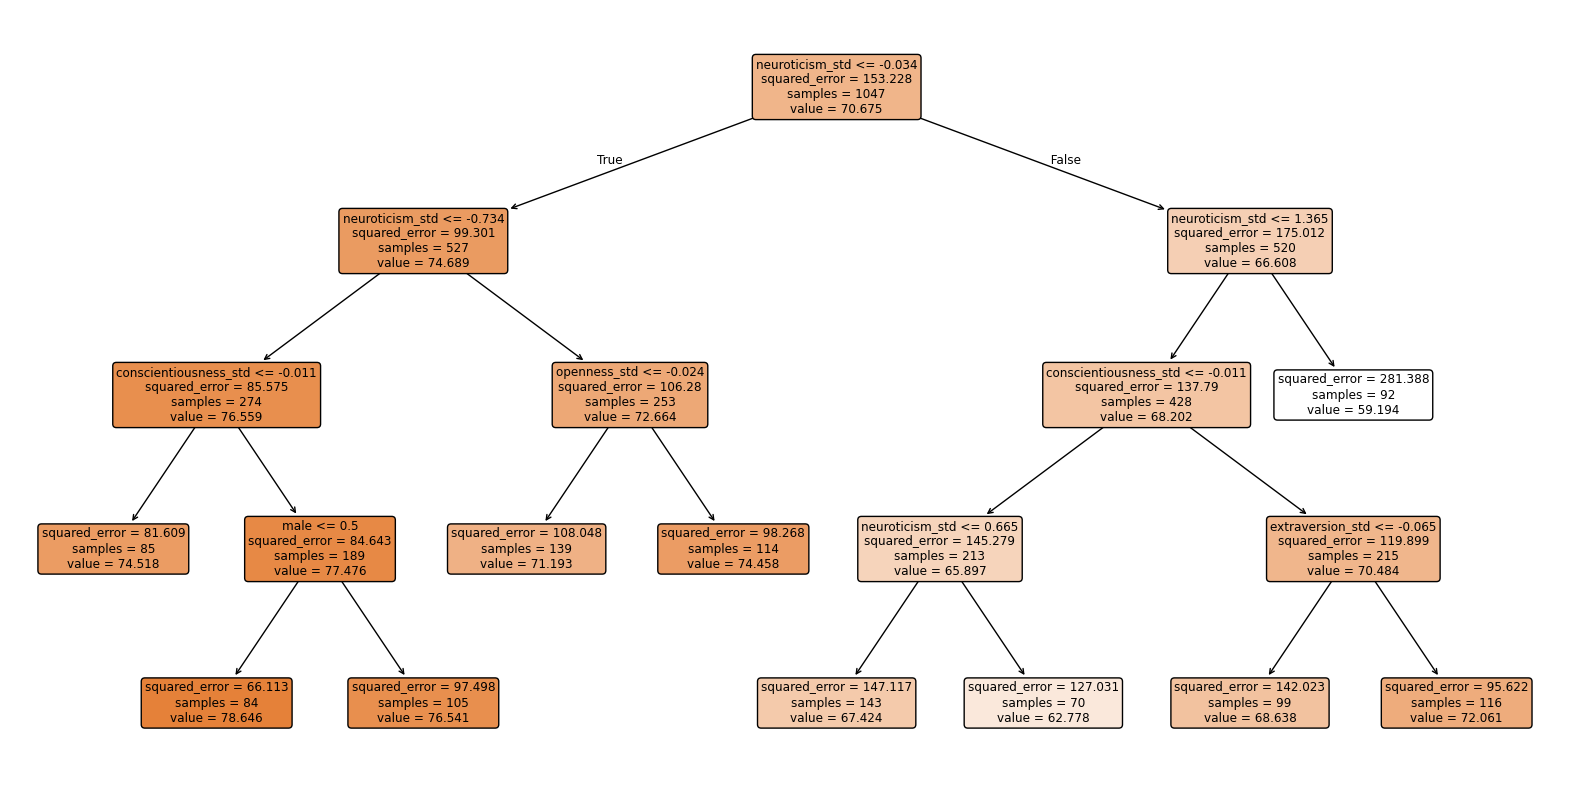

In [267]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=features,
    filled=True,
    rounded=True)

In [268]:
print("Feature Importance:")
for feat, imp in zip(features, tree_model.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.022
  neuroticism_std: 0.860
  agreeableness_std: 0.000
  extraversion_std: 0.021
  conscientiousness_std: 0.091
  male: 0.007


Assigning each terminal node to a dummy variable

In [269]:
terminal_indices = tree_model.apply(X)

In [270]:
print(f"# of observations: {len(terminal_indices)}")
print(f"Each unique terminal node: {np.unique(terminal_indices)}")
print(f"# of terminal nodes: {tree_model.get_n_leaves()}")

# of observations: 1047
Each unique terminal node: [ 3  5  6  8  9 13 14 16 17 18]
# of terminal nodes: 10


In [271]:
df['terminal_node'] = terminal_indices

In [272]:
terminal_dummies = pd.get_dummies(df['terminal_node'], prefix='leaf')
df = pd.concat([df, terminal_dummies], axis=1)

In [273]:
df.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,leaf_3,leaf_5,leaf_6,leaf_8,leaf_9,leaf_13,leaf_14,leaf_16,leaf_17,leaf_18
0,68035365,57.041667,2493.496375,1,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True
1,68058485,64.291667,4008.875375,1,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,True
2,68058489,64.291667,4008.875375,0,0,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
3,68064609,57.291667,4231.804125,0,0,0,0,0,1,0,...,False,False,False,False,True,False,False,False,False,False
4,68097245,58.791667,1964.208062,0,0,0,0,0,1,0,...,False,False,False,False,False,False,True,False,False,False


merging the terminal nodes back to the full df (df_old)

In [274]:
df_old = df_old.merge(df[['pidp', 'terminal_node']], on='pidp', how='left')

relative income measure taking mean (median) of the node and running FE with lincome avdincome and medincome

In [275]:
# Leave-one-out mean income within terminal node
group_sum = df_old.groupby("terminal_node")["lincome"].transform("sum")
group_count = df_old.groupby("terminal_node")["lincome"].transform("count")

df_old["avgincome"] = np.where(
    group_count > 1,
    (group_sum - df_old["lincome"]) / (group_count - 1),
    np.nan)

# Leave-one-out median income within terminal node
def loo_median(series):
    arr = series.to_numpy()
    out = np.full(len(arr), np.nan)
    for i in range(len(arr)):
        others = np.delete(arr, i)
        others = others[~np.isnan(others)]
        if len(others) > 0:
            out[i] = np.median(others)
    return pd.Series(out, index=series.index)

df_old["medincome"] = (
    df_old.groupby("terminal_node")["lincome"]
    .apply(loo_median)
    .reset_index(level=0, drop=True))

**running** fixed effect regression within the full dataset WITH LOG INCOME

In [276]:
for i, leaf in enumerate(sorted(df_old['terminal_node'].dropna().unique()), start=1):
    subgroup = df_old[df_old['terminal_node'] == leaf].copy()

    # IMPORTANT: align rows for formula + clustering
    subgroup = subgroup[['pomst', 'lincome', 'lincome_sq', 'pidp']].dropna()

    # If a leaf has too few rows/clusters, skip (optional but avoids other errors)
    if subgroup.empty or subgroup['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup)}, clusters={subgroup['pidp'].nunique()})")
        continue

    model = smf.ols('pomst ~ lincome + lincome_sq + C(pidp)', data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']}
    )

    print(f"\nSubtree {i} (leaf {leaf})")
    print("Number of individuals:", subgroup['pidp'].nunique())
    print("Number of observations:", len(subgroup))
    print(model.summary())


Subtree 1 (leaf 3)
Number of individuals: 85
Number of observations: 2038
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     6.611
Date:                Wed, 11 Mar 2026   Prob (F-statistic):            0.00216
Time:                        09:52:43   Log-Likelihood:                -8451.4
No. Observations:                2038   AIC:                         1.708e+04
Df Residuals:                    1951   BIC:                         1.757e+04
Df Model:                          86                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 86, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 2
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     8.223
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000552
Time:                        09:52:43   Log-Likelihood:                -8636.2
No. Observations:                2016   AIC:                         1.744e+04
Df Residuals:                    1930   BIC:                         1.793e+04
Df Model:                          85                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               87.9163 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 106, but rank is 2
  warnings.warn('covariance of constraints does not have full '



Subtree 4 (leaf 8)
Number of individuals: 139
Number of observations: 3335


...


Subtree 9 (leaf 17)
Number of individuals: 116
Number of observations: 2782
                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     9.356
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000172
Time:                        09:52:50   Log-Likelihood:                -11780.
No. Observations:                2782   AIC:                         2.380e+04
Df Residuals:                    2664   BIC:                         2.450e+04
Df Model:                         117                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 117, but rank is 2
  warnings.warn('covariance of constraints does not have full '



Subtree 10 (leaf 18)
Number of individuals: 92
Number of observations: 2205


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 93, but rank is 2
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                  pomst   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     302.8
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           6.06e-41
Time:                        09:52:50   Log-Likelihood:                -9462.2
No. Observations:                2205   AIC:                         1.911e+04
Df Residuals:                    2111   BIC:                         1.965e+04
Df Model:                          93                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                9.5735 

In [277]:
for leaf in sorted(df_old['terminal_node'].unique()):
    subgroup = df_old[df_old['terminal_node'] == leaf]

    # IMPORTANT: align rows for formula + clustering
    subgroup = subgroup[['pomst', 'lincome', 'lincome_sq', 'pidp']].dropna()

    # If a leaf has too few rows/clusters, skip (optional but avoids other errors)
    if subgroup.empty or subgroup['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup)}, clusters={subgroup['pidp'].nunique()})")
        continue

    model = smf.ols('pomst ~ lincome + lincome_sq + C(pidp)', data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']}
    )

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))
    print("lincome coef:", model.params.get('lincome', np.nan))
    print("lincome_sq coef:", model.params.get('lincome_sq', np.nan))
    print("SE(lincome):", model.bse.get('lincome', np.nan))
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 3
Individuals: 85
Observations: 2038
lincome coef: 12.066671027889408
lincome_sq coef: -0.8766598681727624
SE(lincome): 2.6533457602023223
SE(lincome_sq): 0.2002042809323068
p(lincome): 5.423046681948602e-06
p(lincome_sq): 1.1931991890725716e-05

Leaf 5
Individuals: 84
Observations: 2016
lincome coef: -0.48004848622439167
lincome_sq coef: -0.018558024950527233
SE(lincome): 5.744232830323344
SE(lincome_sq): 0.39122895005494884
p(lincome): 0.9333979118672924
p(lincome_sq): 0.9621663720697943

Leaf 6
Individuals: 105
Observations: 2518
lincome coef: -3.194112289490172
lincome_sq coef: 0.30977323910801763
SE(lincome): 7.168330539661385
SE(lincome_sq): 0.49127568562165036
p(lincome): 0.6558958659191201
p(lincome_sq): 0.528335658286923

Leaf 8
Individuals: 139
Observations: 3335
lincome coef: 9.092641714442887
lincome_sq coef: -0.666924475718398
SE(lincome): 8.531863715884358
SE(lincome_sq): 0.5573413591650147
p(lincome): 0.2865468464898737
p(lincome_sq): 0.23145564000436814

Leaf 9
In

doing FE regression again this time now with lincome and avgincome/medincome

In [278]:
for leaf in sorted(df_old['terminal_node'].dropna().unique()):
    subgroup = df_old[df_old['terminal_node'] == leaf].copy()

    subgroup = subgroup[['pomst', 'lincome', 'lincome_sq', 'avgincome', 'pidp']].dropna()

    if subgroup.empty or subgroup['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup)}, clusters={subgroup['pidp'].nunique()})")
        continue

    model = smf.ols('pomst ~ lincome + lincome_sq + avgincome + C(pidp)', data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']})

    print(f"\nLeaf {leaf} | FE: lincome + lincome_sq + avgincome")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))
    print("avgincome coef:", model.params.get('avgincome', np.nan))
    print("lincome coef:", model.params.get('lincome', np.nan))
    print("lincome_sq coef:", model.params.get('lincome_sq', np.nan))
    print("SE(lincome):", model.bse.get('lincome', np.nan))
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 3 | FE: lincome + lincome_sq + avgincome
Individuals: 85
Observations: 2038
avgincome coef: 3.7720196063839646
lincome coef: 12.068522780273472
lincome_sq coef: -0.8766598681727246
SE(lincome): 2.653469326927922
SE(lincome_sq): 0.2002556087836473
p(lincome): 5.410538744566234e-06
p(lincome_sq): 1.1993584077010082e-05

Leaf 5 | FE: lincome + lincome_sq + avgincome
Individuals: 84
Observations: 2016
avgincome coef: 10.721337738812213
lincome coef: -0.47472772307859334
lincome_sq coef: -0.01855802495049321
SE(lincome): 5.744449959956081
SE(lincome_sq): 0.3913303441087804
p(lincome): 0.9341369117204094
p(lincome_sq): 0.9621761674505194

Leaf 6 | FE: lincome + lincome_sq + avgincome
Individuals: 105
Observations: 2518
avgincome coef: 10.636119449036972
lincome coef: -3.189886576558667
lincome_sq coef: 0.3097732391080277
SE(lincome): 7.168591809112196
SE(lincome_sq): 0.49137759946688
p(lincome): 0.6563335428878164
p(lincome_sq): 0.5284211961698915

Leaf 8 | FE: lincome + lincome_sq + a

In [279]:
for leaf in sorted(df_old['terminal_node'].dropna().unique()):
    subgroup = df_old[df_old['terminal_node'] == leaf].copy()

    subgroup = subgroup[['pomst', 'lincome', 'lincome_sq', 'medincome', 'pidp']].dropna()

    if subgroup.empty or subgroup['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup)}, clusters={subgroup['pidp'].nunique()})")
        continue

    model = smf.ols('pomst ~ lincome + lincome_sq + medincome + C(pidp)', data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']})

    print(f"\nLeaf {leaf} | FE: lincome + lincome_sq + medincome")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))
    print("medincome coef:", model.params.get('medincome', np.nan))
    print("lincome coef:", model.params.get('lincome', np.nan))
    print("lincome_sq coef:", model.params.get('lincome_sq', np.nan))
    print("SE(lincome):", model.bse.get('lincome', np.nan))
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 3 | FE: lincome + lincome_sq + medincome
Individuals: 85
Observations: 2038
medincome coef: 2108.219385217165
lincome coef: 12.01957235567447
lincome_sq coef: -0.8714579019115819
SE(lincome): 2.4557628675016807
SE(lincome_sq): 0.19232886416743245
p(lincome): 9.85884264493985e-07
p(lincome_sq): 5.868228511051767e-06

Leaf 5 | FE: lincome + lincome_sq + medincome
Individuals: 84
Observations: 2016
medincome coef: 450.18304044927163
lincome coef: -0.8384377579857001
lincome_sq coef: 0.01812892834881849
SE(lincome): 6.025883973233616
SE(lincome_sq): 0.43550841488780223
p(lincome): 0.889340010391043
p(lincome_sq): 0.9667960131962191

Leaf 6 | FE: lincome + lincome_sq + medincome
Individuals: 105
Observations: 2518
medincome coef: -453.36403613172297
lincome coef: -2.2715398969171336
lincome_sq coef: 0.22117574980833013
SE(lincome): 7.352548951471911
SE(lincome_sq): 0.5152421680998504
p(lincome): 0.7573626758588594
p(lincome_sq): 0.6677299319770273

Leaf 8 | FE: lincome + lincome_sq + 

adding age, square of age and marital status then estimating a model for each tree to examine relationship between life satisfaction and income

In [280]:
for i, leaf in enumerate(sorted(df_old['terminal_node'].dropna().unique()), start=1):
    subgroup = df_old[df_old['terminal_node'] == leaf].copy()

    # Keep only needed columns and drop rows with any missing values
    subgroup = subgroup[['pomst', 'lincome', 'lincome_sq',
                         'agenew', 'agesq', 'single', 'married', 'others', 'pidp']].dropna()

    # Skip tiny leaves (cluster SE needs >=2 clusters)
    if subgroup.empty or subgroup['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup)}, clusters={subgroup['pidp'].nunique()})")
        continue

    regression_new = 'pomst ~ lincome + lincome_sq + agenew + agesq + single + married + others + C(pidp)'

    model = smf.ols(regression_new, data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']}
    )

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))

    print("lincome coef:", model.params['lincome'])
    print("lincome_sq coef:", model.params['lincome_sq'])
    print("Age coef:", model.params['agenew'])
    print("Age^2 coef:", model.params['agesq'])
    print("Single coef:", model.params['single'])
    print("Married coef:", model.params['married'])
    print("Others coef:", model.params['others'])

    print("SE(lincome):", model.bse.get('lincome', np.nan))
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 3
Individuals: 85
Observations: 2038
lincome coef: 12.136404276409275
lincome_sq coef: -0.8798863981727795
Age coef: 0.5096111920450493
Age^2 coef: -0.0035748935237130686
Single coef: 1.798609355332172
Married coef: 4.047083990495324
Others coef: 2.762084863752821
SE(lincome): 2.778734810210525
SE(lincome_sq): 0.2086282782573058
p(lincome): 1.2561884710923684e-05
p(lincome_sq): 2.470434864570824e-05

Leaf 5
Individuals: 84
Observations: 2016
lincome coef: -0.26351526782832746
lincome_sq coef: -0.06538308118809925
Age coef: 0.00010067937661412119
Age^2 coef: -0.0002285583411983439
Single coef: 22.810392702669727
Married coef: 23.939204518863416
Others coef: 19.539424938659163
SE(lincome): 5.342944253856031
SE(lincome_sq): 0.3648367669416901
p(lincome): 0.9606640936977761
p(lincome_sq): 0.8577713395249571

Leaf 6
Individuals: 105
Observations: 2518
lincome coef: -3.6108339774543277
lincome_sq coef: 0.3112594480703028
Age coef: -0.29951673745748536
Age^2 coef: 0.0028893561040442338


now instead adding age, square of age and education then estimating a model for each tree to examine relationship between life satisfaction and income

In [281]:
for i, leaf in enumerate(sorted(df_old['terminal_node'].dropna().unique()), start=1):
    subgroup = df_old[df_old['terminal_node'] == leaf].copy()

    # Align rows used by the regression and the clustering
    subgroup = subgroup[['pomst','lincome','lincome_sq','agenew','agesq',
                         'neduc','ueduc','oheduc','Alevel','gcse','otheduc','pidp']].dropna()

    if subgroup.empty or subgroup['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup)}, clusters={subgroup['pidp'].nunique()})")
        continue

    regression_new = 'pomst ~ lincome + lincome_sq + agenew + agesq + neduc + ueduc + oheduc + Alevel + gcse + otheduc + C(pidp)'
    model = smf.ols(regression_new, data=subgroup).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup['pidp']}
    )

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup['pidp'].nunique())
    print("Observations:", len(subgroup))

    print("lincome coef:", model.params['lincome'])
    print("lincome_sq coef:", model.params['lincome_sq'])
    print("Age coef:", model.params['agenew'])
    print("Age^2 coef:", model.params['agesq'])
    print("No Education coef:", model.params['neduc'])
    print("University Education coef:", model.params['ueduc'])
    print("Other higher Education coef:", model.params['oheduc'])
    print("GCSE coef:", model.params['gcse'])
    print("A-level coef:", model.params['Alevel'])
    print("Other Education coef:", model.params['otheduc'])

    print("SE(lincome):", model.bse.get('lincome', np.nan))
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 3
Individuals: 85
Observations: 2038
lincome coef: 12.348685400168712
lincome_sq coef: -0.8972764301204
Age coef: 0.48113299087614
Age^2 coef: -0.0032560230252858327
No Education coef: 10.048780454455551
University Education coef: 14.11056802768365
Other higher Education coef: -26.434131039319503
GCSE coef: 7.432964643550742
A-level coef: 7.427485712429593
Other Education coef: -10.143135089725282
SE(lincome): 2.703408926171403
SE(lincome_sq): 0.2030418549145726
p(lincome): 4.928229217443118e-06
p(lincome_sq): 9.908078686128398e-06

Leaf 5
Individuals: 84
Observations: 2016
lincome coef: -0.952524985488326
lincome_sq coef: 0.0052669782371393414
Age coef: 0.07171151077863419
Age^2 coef: -0.0012059422983357224
No Education coef: 5.562806815986911
University Education coef: 8.167490667433619
Other higher Education coef: 18.634215698444212
GCSE coef: 7.808203267297266
A-level coef: 5.966768375108085
Other Education coef: 25.615346547142927
SE(lincome): 5.365577764456993
SE(lincome_sq

including lincome to classify individuals

In [282]:
features2 = features + ['lincome']

In [283]:
df_tree2 = df[features2 + [target]].dropna()

In [284]:
df_tree2.head()

,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,male,lincome,pomst
0,1.134772,1.714700,1.334850,0.318156,-0.471428,1,7.793500,40.972220
1,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,1,8.152248,58.333329
2,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,0,8.152248,78.472226
3,0.362247,-0.383959,1.334850,1.085346,1.368915,0,8.226963,61.111114
4,1.134772,1.015147,0.354012,1.852535,-0.471428,0,7.398608,65.972222


In [285]:
# Prepare X and y
X2 = df_tree2[features2]
y2 = df_tree2[target]

In [286]:
tree_model2 = dtr(min_samples_leaf=75, criterion='squared_error', splitter='best',random_state=17)
tree_model2.fit(X2, y2)

DecisionTreeRegressor(min_samples_leaf=75, random_state=17)

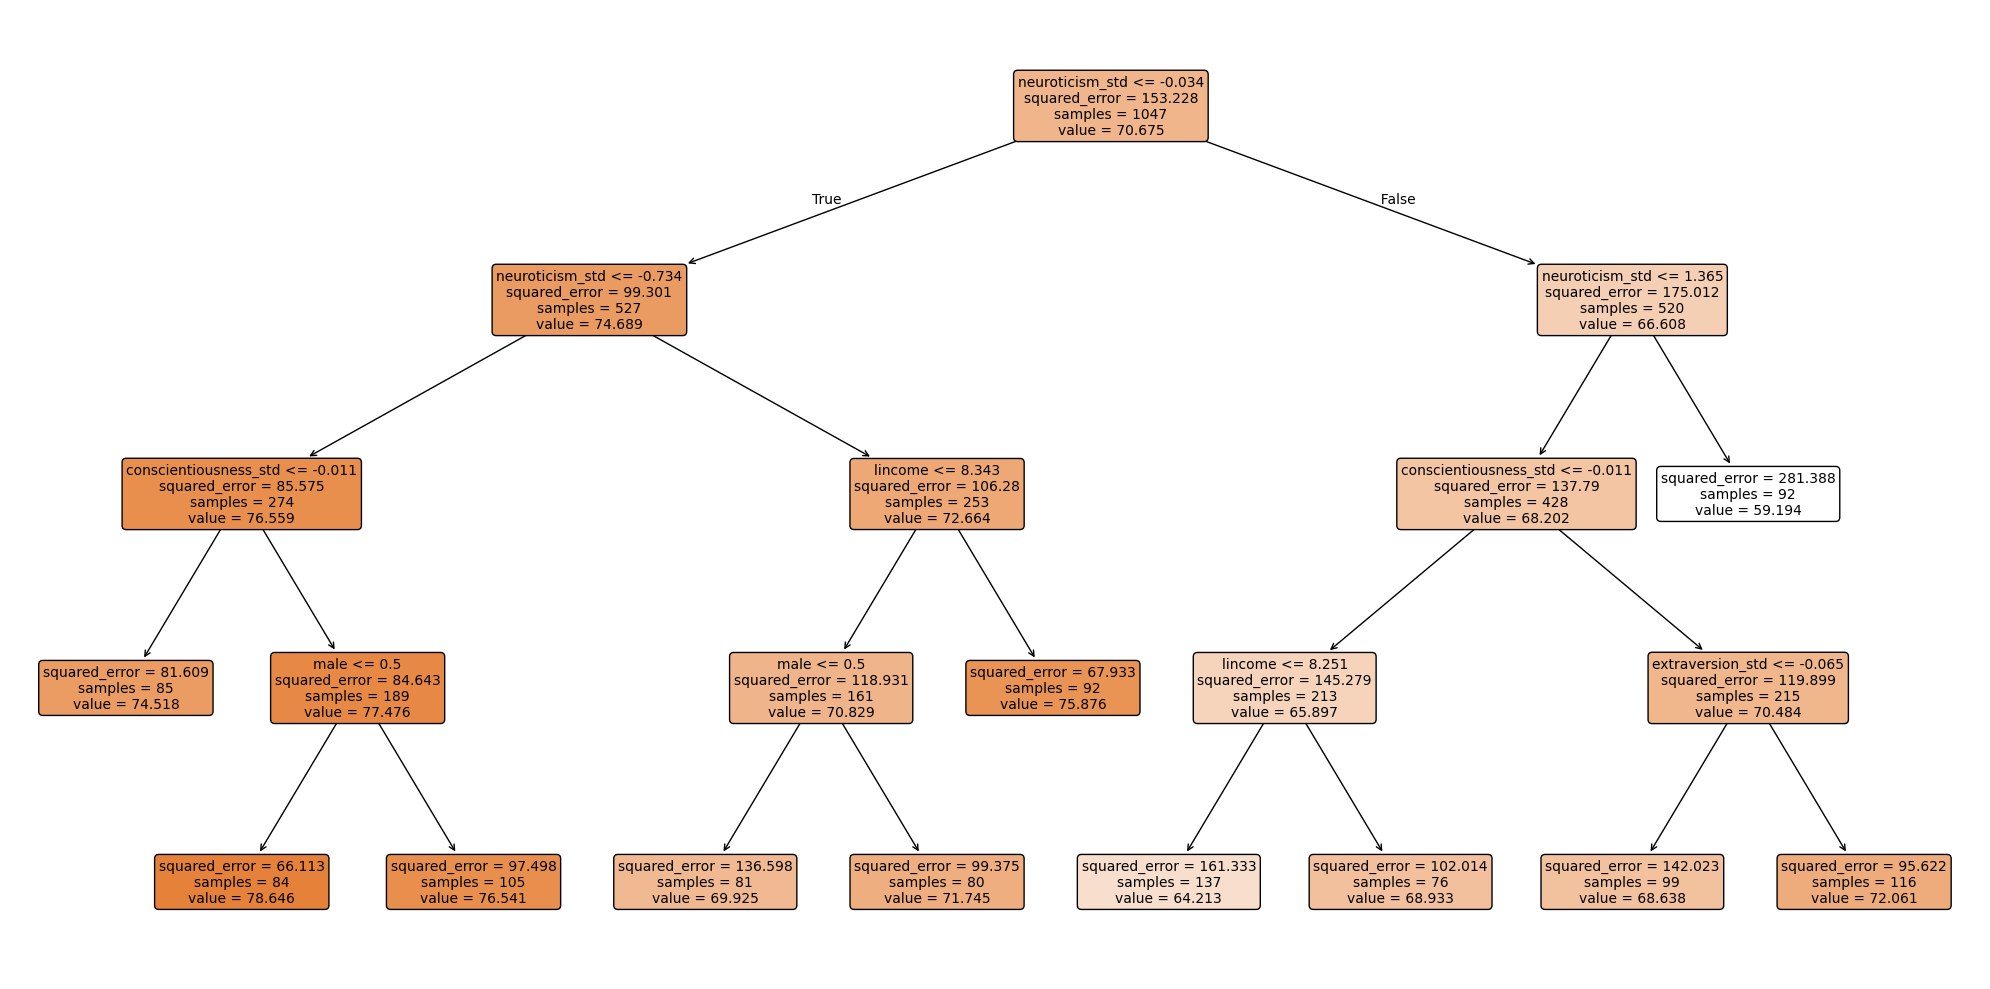

In [287]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model2,
          feature_names=features2,
          filled=True,
          rounded=True,
          fontsize=10)
plt.tight_layout()

In [288]:
print("Feature Importance:")
for feat, imp in zip(features2, tree_model2.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.000
  neuroticism_std: 0.800
  agreeableness_std: 0.000
  extraversion_std: 0.020
  conscientiousness_std: 0.088
  male: 0.011
  lincome: 0.082


purely classifying decision trees seperately by gender

In [289]:
features3 = traits + ['neduc','ueduc','oheduc','Alevel','gcse','otheduc']
target = 'pomst'

In [290]:
df_m = df[df['male'] == 1].copy()
df_f = df[df['male'] == 0].copy()

df_tree3 = df_m[['pidp'] + features3 + [target]].dropna().copy()
df_tree4 = df_f[['pidp'] + features3 + [target]].dropna().copy()

print("Males:", len(df_m), "Females:", len(df_f))

Males: 457 Females: 590


In [291]:
# Prepare X and y
X3 = df_tree3[features3]
y3 = df_tree3[target]

# Train/test split

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size=0.2,
    random_state=20)

# Prepare X and y

X4 = df_tree4[features3]
y4 = df_tree4[target]

# Train/test split

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4,
    test_size=0.2,
    random_state=20)

male dec tree

In [292]:
cart = dtr(random_state=17)

grid_male = GridSearchCV(
    estimator=cart,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_male.fit(X3_train, y3_train)

print("Best parameters (Male):")
print(grid_male.best_params_)
print("Best CV score (Male):", grid_male.best_score_)

Best parameters (Male):
{'ccp_alpha': 0, 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 50}
Best CV score (Male): -99.01199610885347


In [293]:
tree_model3 = grid_male.best_estimator_

In [294]:
y_pred_m = tree_model3.predict(X3_test)

rmse_m = np.sqrt(mean_squared_error(y3_test, y_pred_m))

print("Test RMSE (Male CART):", rmse_m)

Test RMSE (Male CART): 12.460803808635543


In [295]:
y_pred_m = tree_model3.predict(X3_test)

rmse_m = np.sqrt(mean_squared_error(y3_test, y_pred_m))

print("Test RMSE (Male CART):", rmse_m)

Test RMSE (Male CART): 12.460803808635543


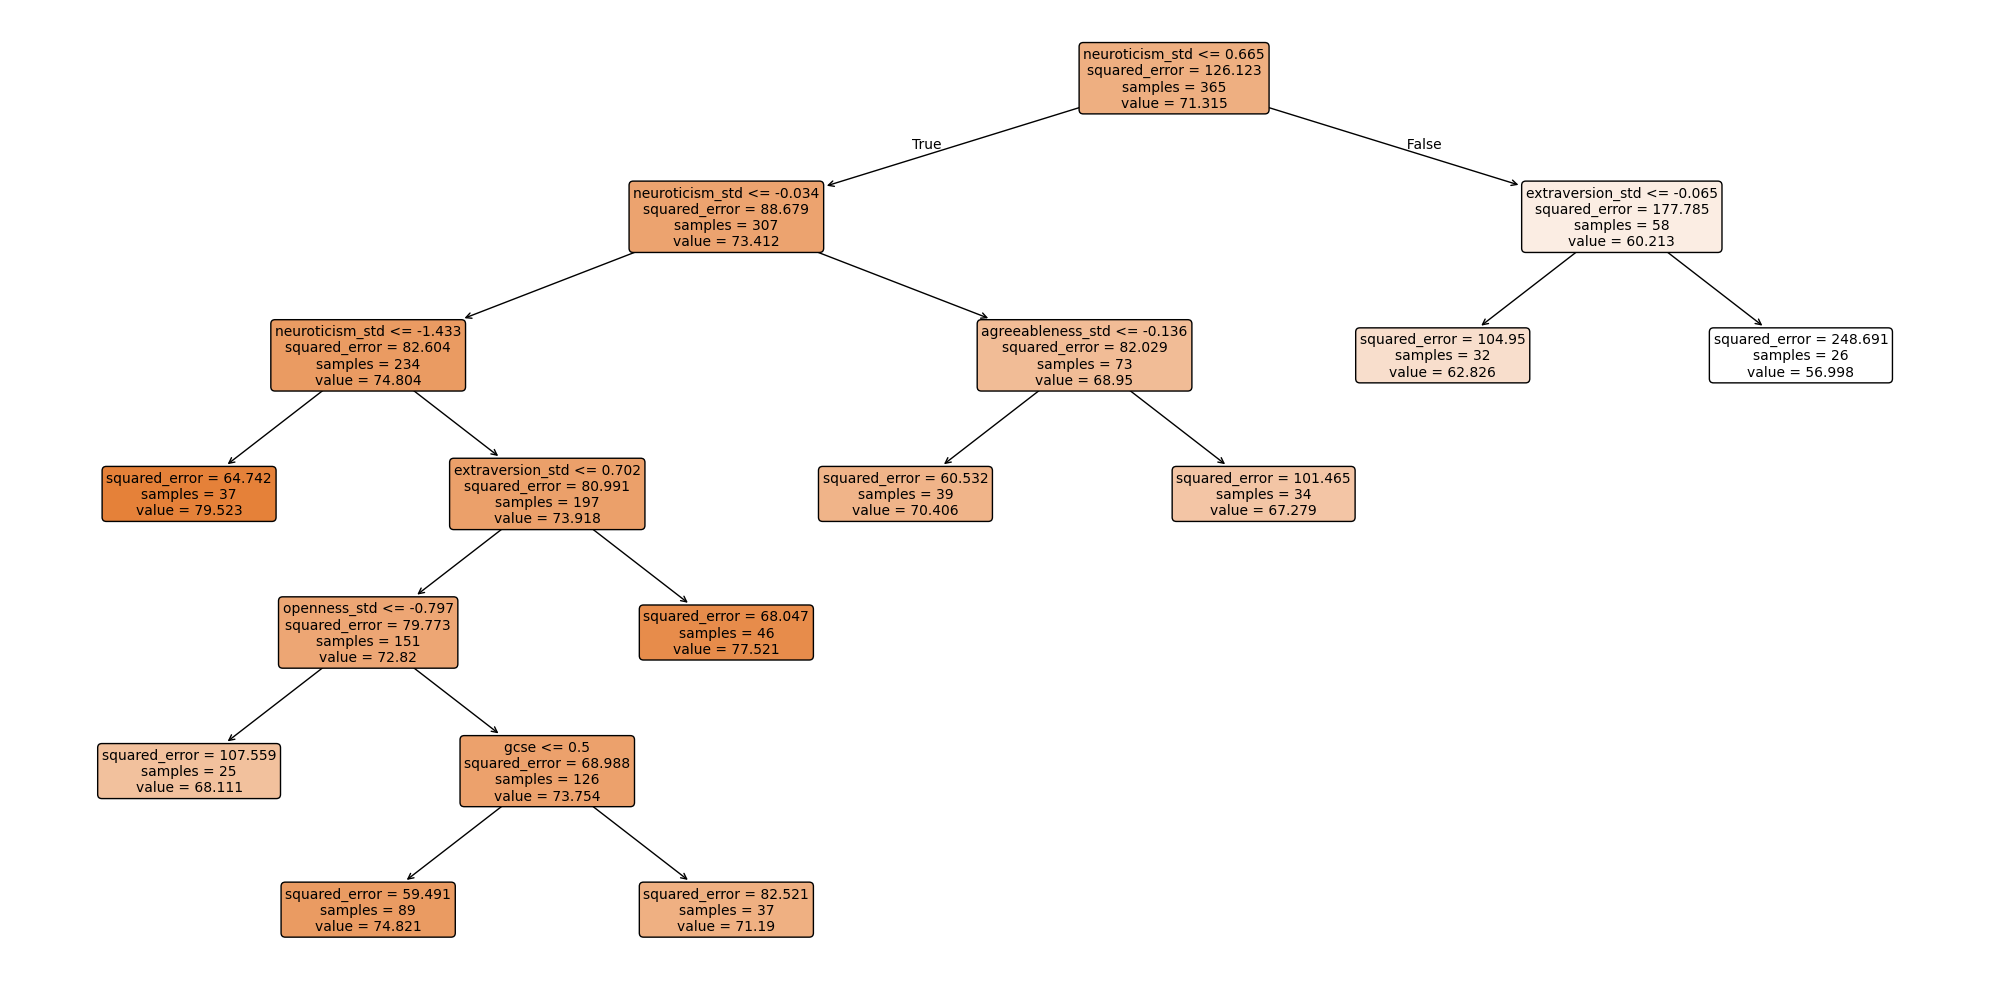

In [296]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model3,
    feature_names=features3,
    filled=True,
    rounded=True,
    fontsize=10)
plt.tight_layout()

In [297]:
print("Feature Importance:")
for feat, imp in zip(features3, tree_model3.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.048
  neuroticism_std: 0.823
  agreeableness_std: 0.013
  extraversion_std: 0.092
  conscientiousness_std: 0.000
  neduc: 0.000
  ueduc: 0.000
  oheduc: 0.000
  Alevel: 0.000
  gcse: 0.025
  otheduc: 0.000


female dec tree

In [298]:
cart = dtr(random_state=17)

grid_female = GridSearchCV(
    estimator=cart,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_female.fit(X4_train, y4_train)

print("Best parameters (Female):")
print(grid_female.best_params_)
print("Best CV score (Female):", grid_female.best_score_)

Best parameters (Female):
{'ccp_alpha': 0, 'max_depth': 5, 'min_samples_leaf': 25, 'min_samples_split': 150}
Best CV score (Female): -141.43377912639832


In [299]:
tree_model4 = grid_female.best_estimator_

In [300]:
y_pred_f = tree_model4.predict(X4_test)

rmse_f = np.sqrt(mean_squared_error(y4_test, y_pred_f))

print("Test RMSE (Female CART):", rmse_f)

Test RMSE (Female CART): 12.725461441441492


In [301]:
tree_model4.fit(X4, y4)

DecisionTreeRegressor(ccp_alpha=0, max_depth=5, min_samples_leaf=25,
                      min_samples_split=150, random_state=17)

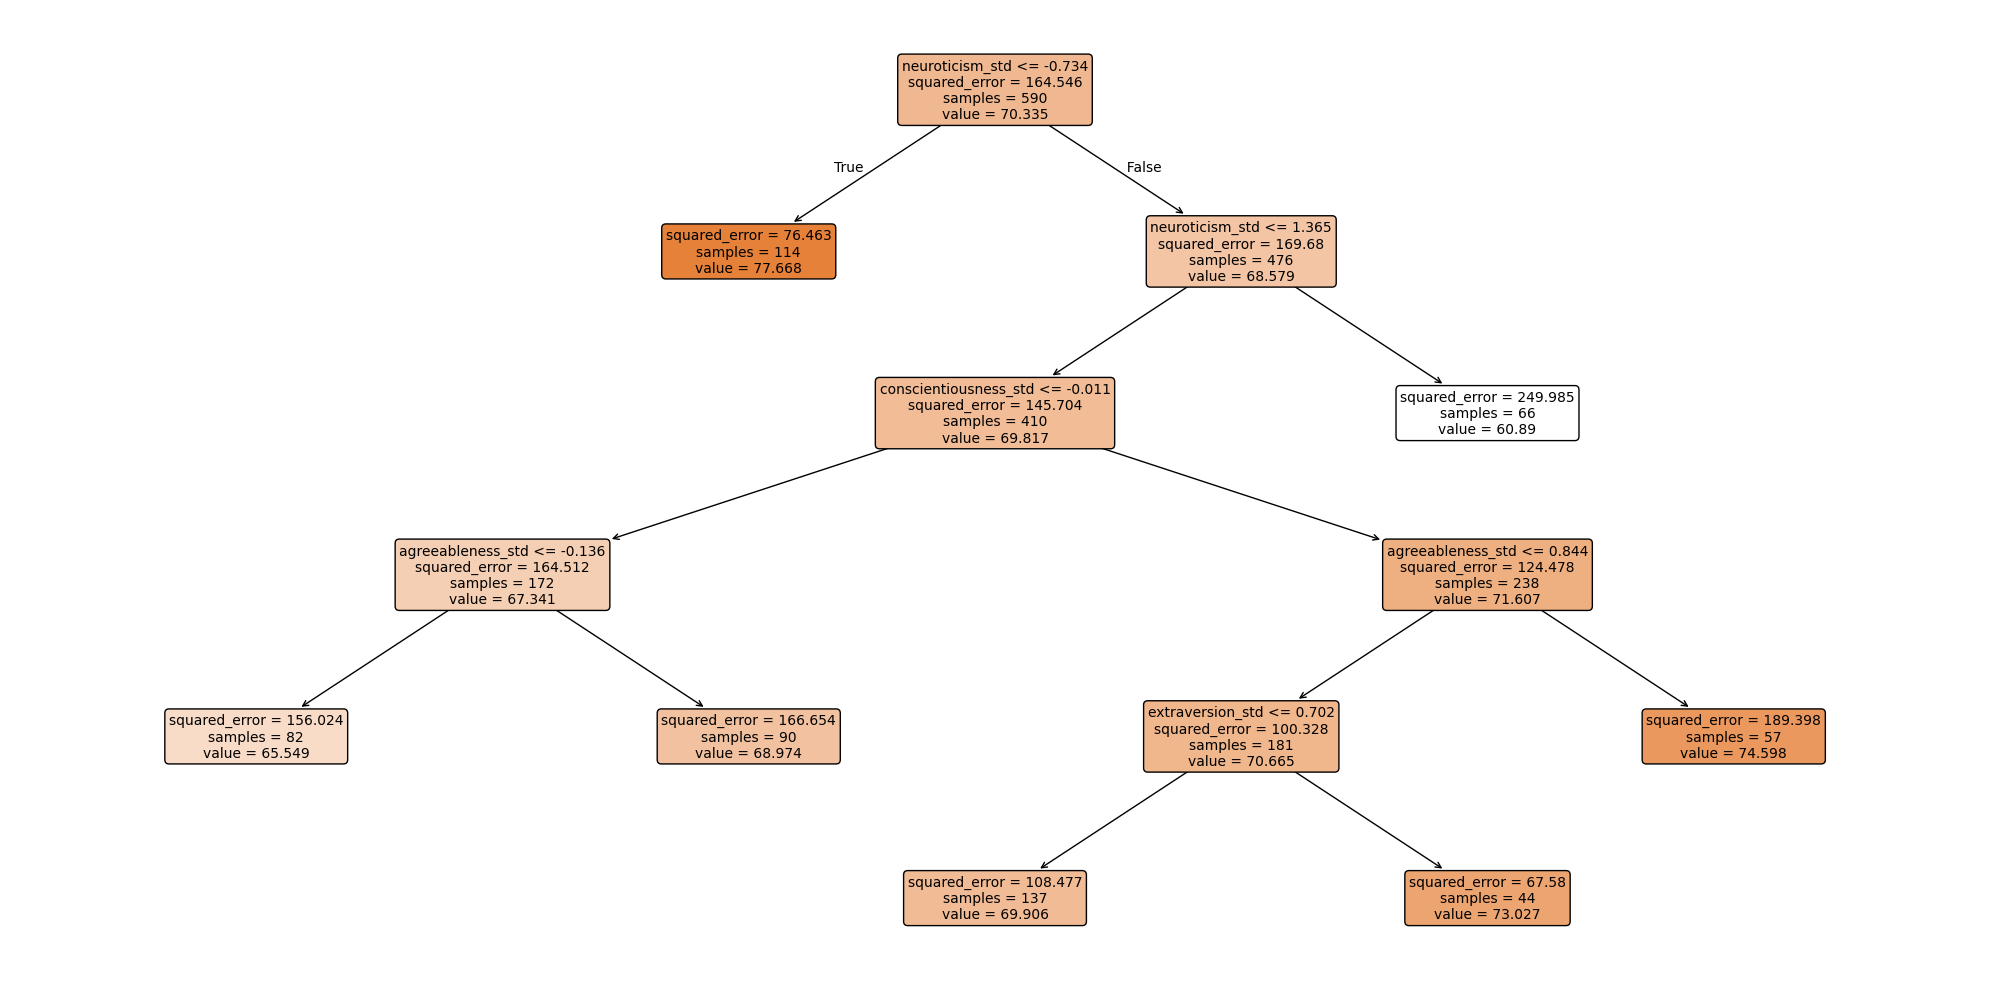

In [302]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model4,
    feature_names=features3,
    filled=True,
    rounded=True,
    fontsize=10)

plt.tight_layout()

In [303]:
print("Feature Importance:")
for feat, imp in zip(features3, tree_model4.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.000
  neuroticism_std: 0.785
  agreeableness_std: 0.076
  extraversion_std: 0.021
  conscientiousness_std: 0.118
  neduc: 0.000
  ueduc: 0.000
  oheduc: 0.000
  Alevel: 0.000
  gcse: 0.000
  otheduc: 0.000


assigning each node to a dummy variable (male)

In [304]:
terminal_indices1 = tree_model3.apply(X3)

print(f"# of observations: {len(terminal_indices1)}")
print(f"Each unique terminal node: {np.unique(terminal_indices1)}")
print(f"# of terminal nodes: {tree_model3.get_n_leaves()}")

# of observations: 457
Each unique terminal node: [ 3  6  8  9 10 12 13 15 16]
# of terminal nodes: 9


In [305]:
df_tree3['terminal_node_m'] = terminal_indices1

terminal_dummies1 = pd.get_dummies(df_tree3['terminal_node_m'], prefix='leaf')
df_tree3 = pd.concat([df_tree3, terminal_dummies1], axis=1)

In [306]:
df_tree3.head()

,pidp,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,neduc,ueduc,oheduc,Alevel,...,terminal_node_m,leaf_3,leaf_6,leaf_8,leaf_9,leaf_10,leaf_12,leaf_13,leaf_15,leaf_16
0,68035365,1.134772,1.714700,1.334850,0.318156,-0.471428,0,0,0,0,...,16,False,False,False,False,False,False,False,False,True
1,68058485,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,0,0,0,0,...,15,False,False,False,False,False,False,False,True,False
7,68138045,1.134772,-0.383959,0.354012,1.852535,0.448744,0,0,1,0,...,10,False,False,False,False,True,False,False,False,False
10,68297845,1.134772,-1.083512,0.354012,1.085346,0.448744,0,0,0,0,...,10,False,False,False,False,True,False,False,False,False
13,68320965,-0.410277,-1.083512,-0.626826,-0.449034,-0.471428,1,0,0,0,...,8,False,False,True,False,False,False,False,False,False


merging the terminal nodes back to the full df (df_old)

In [307]:
df_old_m = df_old[df_old['male'] == 1].copy()
df_old_f = df_old[df_old['male'] == 0].copy()

In [308]:
df_old_m = df_old_m.merge(df_tree3[['pidp', 'terminal_node_m']], on='pidp', how='left')

running fixed effect regression within the full dataset (male)

In [309]:
for leaf in sorted(df_old_m['terminal_node_m'].dropna().unique()):
    subgroup_m = df_old_m[df_old_m['terminal_node_m'] == leaf]


    subgroup_m = subgroup_m[['pomst','lincome','lincome_sq','pidp']].dropna()
    if subgroup_m.empty or subgroup_m['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup_m)}, clusters={subgroup_m['pidp'].nunique()})")
        continue

    model = smf.ols('pomst ~ lincome + lincome_sq + C(pidp)', data=subgroup_m).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup_m['pidp']}
    )

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup_m['pidp'].nunique())
    print("Observations:", len(subgroup_m))
    print("lincome coef:", model.params['lincome'])
    print("lincome_sq coef:", model.params['lincome_sq'])
    print("SE(lincome):", model.bse['lincome'])
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 3
Individuals: 40
Observations: 959
lincome coef: 0.6064129767700701
lincome_sq coef: -0.04325508748199919
SE(lincome): 4.898438234471266
SE(lincome_sq): 0.3908180743192582
p(lincome): 0.901475842537998
p(lincome_sq): 0.9118714393035077

Leaf 6
Individuals: 34
Observations: 816
lincome coef: 19.364963939729186
lincome_sq coef: -1.2745021691273088
SE(lincome): 22.675916845357182
SE(lincome_sq): 1.3841101639338043
p(lincome): 0.3931115634700687
p(lincome_sq): 0.35714975044586517

Leaf 8
Individuals: 111
Observations: 2662
lincome coef: -0.013142978065855404
lincome_sq coef: -0.006970407173069952
SE(lincome): 6.738591782273844
SE(lincome_sq): 0.44036863985025615
p(lincome): 0.9984438035465094
p(lincome_sq): 0.9873711533136975

Leaf 9
Individuals: 46
Observations: 1103
lincome coef: -4.152110195541784
lincome_sq coef: 0.3441755373179002
SE(lincome): 35.564152812243385
SE(lincome_sq): 2.210401793652663
p(lincome): 0.9070582704084185
p(lincome_sq): 0.8762637990963972

Leaf 10
Individua

assigning each node to a dummy variable (female)

In [310]:
terminal_indices2 = tree_model4.apply(X4)

print(f"# of observations: {len(terminal_indices2)}")
print(f"Each unique terminal node: {np.unique(terminal_indices2)}")
print(f"# of terminal nodes: {tree_model4.get_n_leaves()}")

df_tree4['terminal_node_f'] = terminal_indices2

terminal_dummies2 = pd.get_dummies(df_tree4['terminal_node_f'], prefix='leaf')
df_tree4 = pd.concat([df_tree4, terminal_dummies2], axis=1)

df_tree4.head()

# of observations: 590
Each unique terminal node: [ 1  5  6  9 10 11 12]
# of terminal nodes: 7


,pidp,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,neduc,ueduc,oheduc,Alevel,...,otheduc,pomst,terminal_node_f,leaf_1,leaf_5,leaf_6,leaf_9,leaf_10,leaf_11,leaf_12
2,68058489,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,0,0,0,0,...,1,78.472226,5,False,True,False,False,False,False,False
3,68064609,0.362247,-0.383959,1.334850,1.085346,1.368915,0,0,0,0,...,0,61.111114,11,False,False,False,False,False,True,False
4,68097245,1.134772,1.015147,0.354012,1.852535,-0.471428,0,0,0,0,...,0,65.972222,6,False,False,True,False,False,False,False
5,68133285,0.362247,1.015147,0.354012,0.318156,-0.471428,0,0,0,1,...,0,68.055555,6,False,False,True,False,False,False,False
6,68137365,-1.955325,-0.383959,1.334850,1.085346,1.368915,1,0,0,0,...,0,70.138888,11,False,False,False,False,False,True,False


merging the terminal nodes back to the full df (df_old)

In [311]:
df_old_f = df_old_f.merge(df_tree4[['pidp', 'terminal_node_f']], on='pidp', how='left')

running fixed effect regression within the full dataset (female)

In [312]:
for leaf in sorted(df_old_f['terminal_node_f'].dropna().unique()):
    subgroup_f = df_old_f[df_old_f['terminal_node_f'] == leaf]

    # Align rows for regression + clustering
    subgroup_f = subgroup_f[['pomst','lincome','lincome_sq','pidp']].dropna()

    # Skip if too few individuals
    if subgroup_f.empty or subgroup_f['pidp'].nunique() < 2:
        print(f"\nLeaf {leaf} skipped (obs={len(subgroup_f)}, clusters={subgroup_f['pidp'].nunique()})")
        continue

    model = smf.ols('pomst ~ lincome + lincome_sq + C(pidp)', data=subgroup_f).fit(
        cov_type='cluster',
        cov_kwds={'groups': subgroup_f['pidp']}
    )

    print(f"\nLeaf {leaf}")
    print("Individuals:", subgroup_f['pidp'].nunique())
    print("Observations:", len(subgroup_f))
    print("lincome coef:", model.params['lincome'])
    print("lincome_sq coef:", model.params['lincome_sq'])
    print("SE(lincome):", model.bse['lincome'])
    print("SE(lincome_sq):", model.bse.get('lincome_sq', np.nan))
    print("p(lincome):", model.pvalues.get('lincome', np.nan))
    print("p(lincome_sq):", model.pvalues.get('lincome_sq', np.nan))


Leaf 1.0
Individuals: 114
Observations: 2735
lincome coef: 1.163615304811172
lincome_sq coef: -0.14985337042947108
SE(lincome): 5.487276006219088
SE(lincome_sq): 0.3698999715621417
p(lincome): 0.8320625634040173
p(lincome_sq): 0.6853903115165745

Leaf 5.0
Individuals: 82
Observations: 1966
lincome coef: 14.227352313394801
lincome_sq coef: -1.095220855899643
SE(lincome): 6.383243442179248
SE(lincome_sq): 0.43300067560366984
p(lincome): 0.02582325949667218
p(lincome_sq): 0.011426603941658365

Leaf 6.0
Individuals: 90
Observations: 2160
lincome coef: 2.0074019021918352
lincome_sq coef: -0.23470750841408297
SE(lincome): 1.836533724951333
SE(lincome_sq): 0.1549388915843132
p(lincome): 0.27437693585639966
p(lincome_sq): 0.12981312762520383

Leaf 9.0
Individuals: 137
Observations: 3286
lincome coef: 4.10227311132223
lincome_sq coef: -0.3248916529851452
SE(lincome): 3.6676630945565245
SE(lincome_sq): 0.27483635328034245
p(lincome): 0.2633544445634286
p(lincome_sq): 0.23715505391148084

Leaf 1

Runninga  more advanced decision tree that doesn't only use life satisfaction but also linear regression in each terminal node

In [313]:
features_adv = traits + ['incomecpi']
X_adv = df[features_adv]
y_adv = df.loc[X_adv.index, 'pomst']

In [314]:
model_adv = Cubist(
    n_rules=50,
    n_committees=10)

model_adv.fit(X_adv, y_adv)

Cubist(n_committees=10, n_rules=50)

In [315]:
print("Features used:", features_adv)
print("Number of features:", len(features_adv))
print("Coefficient columns:", np.asarray(model_adv.coeffs_).shape)

Features used: ['openness_std', 'neuroticism_std', 'agreeableness_std', 'extraversion_std', 'conscientiousness_std', 'incomecpi']
Number of features: 6
Coefficient columns: (10, 9)


In [316]:
print(model_adv.feature_importances_)
print(features_adv)

   Conditions  Model               Variable
0         0.0  100.0        neuroticism_std
1         0.0   60.0      agreeableness_std
2         0.0   50.0       extraversion_std
3         0.0   50.0  conscientiousness_std
4         0.0   50.0              incomecpi
0         0.0    0.0           openness_std
['openness_std', 'neuroticism_std', 'agreeableness_std', 'extraversion_std', 'conscientiousness_std', 'incomecpi']


In [317]:
print("coeffs shape:", np.asarray(model_adv.coeffs_).shape)
print(np.asarray(model_adv.coeffs_))

coeffs shape: (10, 9)
[[ 6.886173e+01           nan -4.600000e+00  1.100000e+00  9.000000e-01
   1.100000e+00  7.000000e-04  1.000000e+00  1.000000e+00]
 [ 7.179108e+01           nan -5.200000e+00  1.600000e+00           nan
            nan           nan  2.000000e+00  1.000000e+00]
 [ 6.602466e+01           nan -4.000000e+00           nan  1.900000e+00
   2.300000e+00  1.380000e-03  3.000000e+00  1.000000e+00]
 [ 7.175059e+01           nan -5.000000e+00  2.200000e+00           nan
            nan           nan  4.000000e+00  1.000000e+00]
 [ 6.601774e+01           nan -4.200000e+00           nan  1.800000e+00
   2.100000e+00  1.400000e-03  5.000000e+00  1.000000e+00]
 [ 7.175059e+01           nan -5.000000e+00  2.200000e+00           nan
            nan           nan  6.000000e+00  1.000000e+00]
 [ 6.601774e+01           nan -4.200000e+00           nan  1.800000e+00
   2.100000e+00  1.400000e-03  7.000000e+00  1.000000e+00]
 [ 7.175059e+01           nan -5.000000e+00  2.200000e+00    

In [318]:
coeffs = np.asarray(model_adv.coeffs_)

cols = [
"Intercept",
"Openness",
"Neuroticism",
"Agreeableness",
"Extraversion",
"Conscientiousness",
"Income",
"Rule",
"Committee"
]

coef_table = pd.DataFrame(coeffs, columns=cols)

print(coef_table)

   Intercept  Openness  Neuroticism  Agreeableness  Extraversion  \
0   68.86173       NaN         -4.6            1.1           0.9   
1   71.79108       NaN         -5.2            1.6           NaN   
2   66.02466       NaN         -4.0            NaN           1.9   
3   71.75059       NaN         -5.0            2.2           NaN   
4   66.01774       NaN         -4.2            NaN           1.8   
5   71.75059       NaN         -5.0            2.2           NaN   
6   66.01774       NaN         -4.2            NaN           1.8   
7   71.75059       NaN         -5.0            2.2           NaN   
8   66.01774       NaN         -4.2            NaN           1.8   
9   71.75059       NaN         -5.0            2.2           NaN   

   Conscientiousness   Income  Rule  Committee  
0                1.1  0.00070   1.0        1.0  
1                NaN      NaN   2.0        1.0  
2                2.3  0.00138   3.0        1.0  
3                NaN      NaN   4.0        1.0  
4     

In [319]:
from sklearn.metrics import mean_squared_error

pred = model_adv.predict(X_adv)
rmse = np.sqrt(mean_squared_error(y_adv, pred))
print("RMSE:", rmse)

RMSE: 11.054750730290161


In [320]:
df['pomst'].describe()

,pomst
count,1047.000000
mean,70.675476
std,12.384463
min,15.277780
25%,63.888889
50%,72.916665
75%,79.166670
max,97.916668
